 **Source: Kaggle**

 **Dataset name:** banking77

**Dataset URL:** https://www.kaggle.com/datasets/sssonnn/banking77/data?select=train.csv

**Project Title:** AI-Powered Banking Customer Support Intent Classification System

**Domain:** Artificial Intelligence (AI) & Natural Language Processing (NLP)

**Number of features:** 2

**Number of Rows:** 10,003

**Target variable:** label

**Target classes:** 77

**Problem Statement:**

Banks receive a large volume of customer queries related to card payments, cash withdrawals, transfers, account access, identity verification, and other banking services. Manually identifying the intent of each customer query is time-consuming and can lead to inconsistent query routing and slower response times.

This project aims to develop an **AI-powered banking customer support intent classification system** using **Natural Language Processing (NLP) and Machine Learning** to automatically understand customer queries and classify them into one of **77 predefined banking intents**. The system will help identify the customer's requirement quickly and route the query to the appropriate support category, improving customer service efficiency and reducing manual effort.


**Objective:**

The objective of this project is to develop an **AI-powered banking customer support intent classification system** using **NLP and Machine Learning**. The system will preprocess customer queries, convert text into numerical features using **TF-IDF**, and classify queries into **77 banking service intents**. Multiple ML models will be trained, tuned, and evaluated using standard performance metrics. The best model will be deployed using **Streamlit** to provide real-time intent predictions with confidence scores.


**Business Objective:**

The business objective is to **automate the classification and routing of banking customer queries** into the appropriate support categories. This system aims to reduce manual effort, improve response time, ensure accurate query routing, and enhance the overall **customer support experience** through AI-driven automation.


# **Step 0 - Importing Libraries :**

In [1]:
# ==============================
# Data Handling
# ==============================
import pandas as pd
import numpy as np

# ==============================
# Data Visualization
# ==============================
import matplotlib.pyplot as plt

# ==============================
# NLP
# ==============================
import nltk
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ==============================
# Word Cloud
# ==============================
from wordcloud import WordCloud

# ==============================
# Train-Test Split
# ==============================
from sklearn.model_selection import train_test_split, GridSearchCV

# ==============================
# Text Vectorization
# ==============================
from sklearn.feature_extraction.text import TfidfVectorizer

# ==============================
# Machine Learning Models
# ==============================
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# ==============================
# Model Evaluation
# ==============================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ==============================
# Model Saving
# ==============================
import joblib

# ==============================
# Ignore Warnings
# ==============================
import warnings
warnings.filterwarnings("ignore")

In [2]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [5]:
!pip install streamlit-mic-recorder
!pip install openai-whisper
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 74.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 6.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.0/248.0 MB 6.1 MB/s eta 0:00:00
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803980 sha256=c10d89274a4aa41f6b5d44c1172b177e88ae466ead13a9b86d358dfe3d008995
  Stored in directory: /root/.cache/pip/wheels/ca/58/d5/fb4539ad74c3ca81eb40f7eda020ac77d080b33ad57449d485
Successfully built openai-whisper


# **Step 1: Importing the Dataset**

In [6]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/banking77.csv")


# **Step 2: Data Understanding**


In [7]:
# Display first 5 rows
df.head()

,text,label
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [8]:
# Check dataset shape
print("Dataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (10003, 2)
Number of Rows: 10003
Number of Columns: 2


In [9]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10003 non-null  object
 1   label   10003 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [10]:
# Check column names
print("Columns:", df.columns.tolist())

Columns: ['text', 'label']


In [11]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
text     0
label    0
dtype: int64


In [12]:
#Check Target Class Distribution

print("Number of Target Classes:", df["label"].nunique())

print("Class Distribution:")
print(df["label"].value_counts())

Number of Target Classes: 77
Class Distribution:
label
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
                                                   ... 
lost_or_stolen_card                                  82
card_swallowed                                       61
card_acceptance                                      59
virtual_card_not_working                             41
contactless_not_working                              35
Name: count, Length: 77, dtype: int64


In [14]:
#Duplicate records
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


In [15]:
#Check for Incorrect Data
# Check empty or whitespace-only text
incorrect_text = df[
    df["text"].isnull() | (df["text"].astype(str).str.strip() == "")
]

# Check empty or whitespace-only labels
incorrect_label = df[
    df["label"].isnull() | (df["label"].astype(str).str.strip() == "")
]

print("Incorrect/Empty Text Records:", len(incorrect_text))
print("Incorrect/Empty Label Records:", len(incorrect_label))

Incorrect/Empty Text Records: 0
Incorrect/Empty Label Records: 0


In [16]:
df.sample(10, random_state=42)

,text,label
6883,Is it possible for me to change my PIN number?,change_pin
5836,I'm not sure why my card didn't work,declined_card_payment
8601,I don't think my top up worked,top_up_failed
2545,Can you explain why my payment was charged a fee?,card_payment_fee_charged
8697,How long does a transfer from a UK account tak...,balance_not_updated_after_bank_transfer
5573,Why am I getting declines when trying to make ...,declined_transfer
576,What is the $1 transaction on my account?,extra_charge_on_statement
6832,It looks like my card payment was sent back.,reverted_card_payment?
7111,Why am I unable to transfer money when I was a...,beneficiary_not_allowed
439,What if there is an error on the exchange rate?,card_payment_wrong_exchange_rate


In [17]:
#Class imbalance
class_counts = df["label"].value_counts()

print("Class Distribution:")
print(class_counts)

print("Minimum Class Count:", class_counts.min())
print("Maximum Class Count:", class_counts.max())

Class Distribution:
label
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
                                                   ... 
lost_or_stolen_card                                  82
card_swallowed                                       61
card_acceptance                                      59
virtual_card_not_working                             41
contactless_not_working                              35
Name: count, Length: 77, dtype: int64
Minimum Class Count: 35
Maximum Class Count: 187


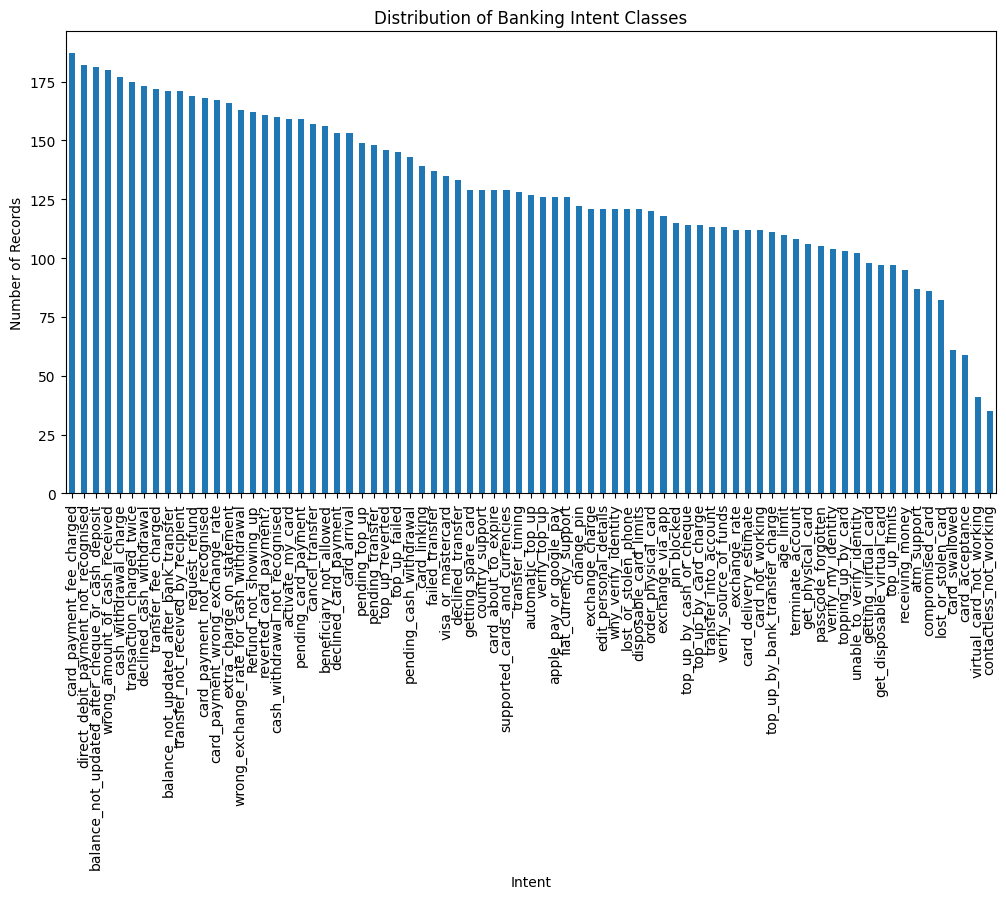

In [18]:
plt.figure(figsize=(12, 6))
class_counts.plot(kind="bar")
plt.title("Distribution of Banking Intent Classes")
plt.xlabel("Intent")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)
plt.show()

In [19]:
#Number of records
print("Total Number of Records:", len(df))

Total Number of Records: 10003


# **Step 3: Text Feature Engineering**


In [20]:
# Create text-based features

# Number of characters
df["char_count"] = df["text"].astype(str).apply(len)

# Number of words
df["word_count"] = df["text"].astype(str).apply(
    lambda x: len(x.split())
)

# Average word length
df["avg_word_length"] = df["text"].astype(str).apply(
    lambda x: sum(len(word) for word in x.split()) / len(x.split())
    if len(x.split()) > 0 else 0
)

# Display the new features
df[["text", "char_count", "word_count", "avg_word_length"]].head()

,text,char_count,word_count,avg_word_length
0,I am still waiting on my card?,30,7,3.428571
1,What can I do if my card still hasn't arrived ...,60,13,3.692308
2,I have been waiting over a week. Is the card s...,58,12,3.916667
3,Can I track my card while it is in the process...,59,13,3.615385
4,"How do I know if I will get my card, or if it ...",54,15,2.666667


In [21]:
df[["char_count", "word_count", "avg_word_length"]].describe()

,char_count,word_count,avg_word_length
count,10003.000000,10003.000000,10003.000000
mean,59.473758,11.949415,4.099165
std,40.867901,7.891577,0.704031
min,13.000000,2.000000,2.333333
25%,36.000000,7.000000,3.625000
50%,47.000000,10.000000,4.000000
75%,64.000000,13.000000,4.500000
max,433.000000,79.000000,9.500000


In [22]:
#Word frequency

from collections import Counter

# Combine all text
all_words = " ".join(df["text"].astype(str).str.lower()).split()

# Count word frequency
word_freq = Counter(all_words)

# Display top 20 most frequent words
print(word_freq.most_common(20))

[('i', 8309), ('my', 5684), ('to', 4011), ('a', 3565), ('the', 3497), ('is', 2339), ('can', 1839), ('do', 1730), ('card', 1636), ('it', 1557), ('for', 1534), ('how', 1511), ('what', 1367), ('why', 1233), ('and', 1213), ('you', 1178), ('was', 1089), ('have', 975), ('not', 953), ('in', 944)]


In [23]:
#Sentence length
df["sentence_length"] = df["text"].astype(str).apply(
    lambda x: len(x.split())
)

df[["text", "sentence_length"]].head()

,text,sentence_length
0,I am still waiting on my card?,7
1,What can I do if my card still hasn't arrived ...,13
2,I have been waiting over a week. Is the card s...,12
3,Can I track my card while it is in the process...,13
4,"How do I know if I will get my card, or if it ...",15


In [24]:
#Important keywords
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Create a temporary TF-IDF vectorizer
keyword_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=20
)

# Fit and transform text
X_keywords = keyword_vectorizer.fit_transform(df["text"])

# Calculate average TF-IDF score for each word
mean_scores = np.asarray(X_keywords.mean(axis=0)).ravel()

# Get words
words = keyword_vectorizer.get_feature_names_out()

# Sort by importance
keyword_df = pd.DataFrame({
    "Keyword": words,
    "Average_TFIDF_Score": mean_scores
}).sort_values(
    by="Average_TFIDF_Score",
    ascending=False
)

print(keyword_df.head(20))

        Keyword  Average_TFIDF_Score
3          card             0.184019
0       account             0.089968
18     transfer             0.076273
11        money             0.075060
14      payment             0.053255
12         need             0.050535
4          cash             0.048851
7      exchange             0.045750
5       charged             0.036411
1           app             0.035016
19          use             0.033981
2           atm             0.032891
8           fee             0.032436
16          pin             0.030031
15      pending             0.029658
6           did             0.027328
17  transaction             0.026913
9          help             0.026775
10         long             0.026580
13          new             0.025569


# **Step 4: Word Cloud**

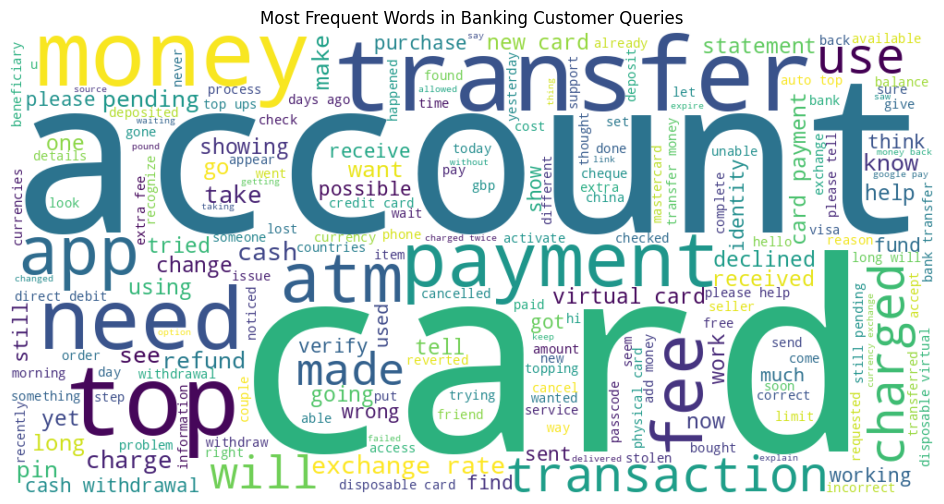

In [25]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all customer queries
text = " ".join(df["text"].astype(str)).lower()

# Create Word Cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=set(WordCloud().stopwords)
).generate(text)

# Display Word Cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Banking Customer Queries")
plt.show()

# **Step 5: Text Preprocessing**


In [30]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [31]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK resources
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

# Stopwords
stop_words = set(stopwords.words("english"))

# Keep important negation words
negation_words = {"no", "not", "never", "nor", "cannot"}
stop_words = stop_words - negation_words

# Lemmatizer
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove unnecessary characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenization
    tokens = word_tokenize(text)

    # Stopword removal
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(tokens)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [32]:
df["clean_text"] = df["text"].apply(preprocess_text)

In [33]:
df[["text", "clean_text"]].head(10)

,text,clean_text
0,I am still waiting on my card?,still waiting card
1,What can I do if my card still hasn't arrived ...,card still hasnt arrived week
2,I have been waiting over a week. Is the card s...,waiting week card still coming
3,Can I track my card while it is in the process...,track card process delivery
4,"How do I know if I will get my card, or if it ...",know get card lost
5,When did you send me my new card?,send new card
6,Do you have info about the card on delivery?,info card delivery
7,What do I do if I still have not received my n...,still not received new card
8,Does the package with my card have tracking?,package card tracking
9,I ordered my card but it still isn't here,ordered card still isnt


# **Step 6 : Input-Output Separation**


In [34]:
# Input feature
X = df["clean_text"]

# Target variable
y = df["label"]

In [35]:
print("Input (X):")
print(X.head())

print("Target (y):")
print(y.head())

Input (X):
0                still waiting card
1     card still hasnt arrived week
2    waiting week card still coming
3       track card process delivery
4                know get card lost
Name: clean_text, dtype: object
Target (y):
0    card_arrival
1    card_arrival
2    card_arrival
3    card_arrival
4    card_arrival
Name: label, dtype: object


# **Step 7: Train-Test Split**


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
print("Total records:", len(X))
print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Total records: 10003
Training records: 8002
Testing records: 2001


In [38]:
#class distribution
print("Training class distribution:")
print(y_train.value_counts())

print("Testing class distribution:")
print(y_test.value_counts())

Training class distribution:
label
card_payment_fee_charged                            149
balance_not_updated_after_cheque_or_cash_deposit    145
direct_debit_payment_not_recognised                 145
wrong_amount_of_cash_received                       144
cash_withdrawal_charge                              141
                                                   ... 
lost_or_stolen_card                                  66
card_swallowed                                       49
card_acceptance                                      47
virtual_card_not_working                             33
contactless_not_working                              28
Name: count, Length: 77, dtype: int64
Testing class distribution:
label
card_payment_fee_charged                            38
direct_debit_payment_not_recognised                 37
wrong_amount_of_cash_received                       36
cash_withdrawal_charge                              36
balance_not_updated_after_cheque_or_cash_deposit    36
  

# **Step 8 : Text Vectorization**


TF-IDF Vectorization

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Fit only on training data
X_train_vec = vectorizer.fit_transform(X_train)

# Transform test data using the same fitted vectorizer
X_test_vec = vectorizer.transform(X_test)

In [40]:
print("Training vector shape:", X_train_vec.shape)
print("Testing vector shape:", X_test_vec.shape)

Training vector shape: (8002, 5875)
Testing vector shape: (2001, 5875)


In [41]:
X_train_vec = vectorizer.fit_transform(X_train)

In [42]:
X_test_vec = vectorizer.transform(X_test)

# **Step 9:  Baseline Model Building**


Logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
model.fit(X_train_vec, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Make Predictions

In [47]:
# Make predictions on the test data
y_pred = model.predict(X_test_vec)

print("Predictions generated successfully!")

Predictions generated successfully!


In [48]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

comparison

,Actual,Predicted
0,unable_to_verify_identity,unable_to_verify_identity
1,card_payment_fee_charged,card_payment_fee_charged
2,card_arrival,card_arrival
3,card_payment_fee_charged,card_payment_fee_charged
4,why_verify_identity,why_verify_identity
5,balance_not_updated_after_bank_transfer,balance_not_updated_after_bank_transfer
6,transfer_not_received_by_recipient,pending_transfer
7,declined_cash_withdrawal,declined_transfer
8,supported_cards_and_currencies,supported_cards_and_currencies
9,request_refund,Refund_not_showing_up


LinearSVC

In [49]:
from sklearn.svm import LinearSVC

# Create LinearSVC model
svc_model = LinearSVC(
    random_state=42,
    max_iter=2000
)

# Train the model
svc_model.fit(X_train_vec, y_train)

print("LinearSVC model trained successfully.")

LinearSVC model trained successfully.


Make predictions

In [50]:
y_pred_svc = svc_model.predict(X_test_vec)

print("First 10 LinearSVC Predictions:")
print(y_pred_svc[:10])

First 10 LinearSVC Predictions:
['unable_to_verify_identity' 'card_not_working' 'card_arrival'
 'card_payment_fee_charged' 'why_verify_identity'
 'balance_not_updated_after_bank_transfer' 'pending_transfer'
 'declined_cash_withdrawal' 'supported_cards_and_currencies'
 'Refund_not_showing_up']


Actual vs Predicted

In [51]:
svc_comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred_svc[:10]
})

svc_comparison

,Actual,Predicted
0,unable_to_verify_identity,unable_to_verify_identity
1,card_payment_fee_charged,card_not_working
2,card_arrival,card_arrival
3,card_payment_fee_charged,card_payment_fee_charged
4,why_verify_identity,why_verify_identity
5,balance_not_updated_after_bank_transfer,balance_not_updated_after_bank_transfer
6,transfer_not_received_by_recipient,pending_transfer
7,declined_cash_withdrawal,declined_cash_withdrawal
8,supported_cards_and_currencies,supported_cards_and_currencies
9,request_refund,Refund_not_showing_up


Random Forest

In [52]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_vec, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


Make predictions

In [53]:
y_pred_rf = rf_model.predict(X_test_vec)

print("First 10 Random Forest Predictions:")
print(y_pred_rf[:10])

First 10 Random Forest Predictions:
['unable_to_verify_identity' 'transfer_fee_charged' 'card_arrival'
 'card_payment_fee_charged' 'why_verify_identity'
 'balance_not_updated_after_bank_transfer'
 'transfer_not_received_by_recipient' 'declined_cash_withdrawal'
 'supported_cards_and_currencies' 'Refund_not_showing_up']


Actual vs Predicted

In [54]:
rf_comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred_rf[:10]
})

rf_comparison

,Actual,Predicted
0,unable_to_verify_identity,unable_to_verify_identity
1,card_payment_fee_charged,transfer_fee_charged
2,card_arrival,card_arrival
3,card_payment_fee_charged,card_payment_fee_charged
4,why_verify_identity,why_verify_identity
5,balance_not_updated_after_bank_transfer,balance_not_updated_after_bank_transfer
6,transfer_not_received_by_recipient,transfer_not_received_by_recipient
7,declined_cash_withdrawal,declined_cash_withdrawal
8,supported_cards_and_currencies,supported_cards_and_currencies
9,request_refund,Refund_not_showing_up


# **Step 10: Model Evaluation**


Logistic Regression

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Predictions
y_pred = model.predict(X_test_vec)

# Evaluation metrics
lr_accuracy = accuracy_score(y_test, y_pred)
lr_precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
lr_recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
lr_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("Logistic Regression")
print("----------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1-Score :", lr_f1)

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Logistic Regression
----------------------------
Accuracy : 0.8360819590204898
Precision: 0.8452199291856642
Recall   : 0.8360819590204898
F1-Score : 0.8360737102882604
Classification Report:
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.91      0.94      0.92        32
                                activate_my_card       0.97      0.94      0.95        32
                                       age_limit       1.00      0.95      0.98        22
                         apple_pay_or_google_pay       0.96      0.96      0.96        25
                                     atm_support       0.80      0.71      0.75        17
                                automatic_top_up       1.00      0.88      0.94        25
         balance_not_updated_after_bank_transfer       0.83      0.71      0.76        34
balance_not_updated_after_cheque_or_cash_deposit       0.81      0.94      0.87        

LinearSVC

In [56]:
# Predictions
y_pred_svc = svc_model.predict(X_test_vec)

# Evaluation metrics
svc_accuracy = accuracy_score(y_test, y_pred_svc)
svc_precision = precision_score(y_test, y_pred_svc, average="weighted", zero_division=0)
svc_recall = recall_score(y_test, y_pred_svc, average="weighted", zero_division=0)
svc_f1 = f1_score(y_test, y_pred_svc, average="weighted", zero_division=0)

print("LinearSVC")
print("----------------------------")
print("Accuracy :", svc_accuracy)
print("Precision:", svc_precision)
print("Recall   :", svc_recall)
print("F1-Score :", svc_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svc, zero_division=0))

LinearSVC
----------------------------
Accuracy : 0.8505747126436781
Precision: 0.8576205487164783
Recall   : 0.8505747126436781
F1-Score : 0.8512802588529874

Classification Report:
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.91      1.00      0.96        32
                                activate_my_card       0.97      0.94      0.95        32
                                       age_limit       1.00      0.95      0.98        22
                         apple_pay_or_google_pay       0.96      0.96      0.96        25
                                     atm_support       0.69      0.65      0.67        17
                                automatic_top_up       1.00      0.92      0.96        25
         balance_not_updated_after_bank_transfer       0.75      0.79      0.77        34
balance_not_updated_after_cheque_or_cash_deposit       0.84      0.86      0.85        36
      

Random Forest

In [57]:
# Predictions
y_pred_rf = rf_model.predict(X_test_vec)

# Evaluation metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average="weighted", zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, average="weighted", zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, average="weighted", zero_division=0)

print("Random Forest")
print("----------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)

print("Classification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest
----------------------------
Accuracy : 0.8160919540229885
Precision: 0.8252079578050316
Recall   : 0.8160919540229885
F1-Score : 0.8158580852039145
Classification Report:
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.87      0.84      0.86        32
                                activate_my_card       0.86      0.97      0.91        32
                                       age_limit       1.00      0.95      0.98        22
                         apple_pay_or_google_pay       1.00      0.96      0.98        25
                                     atm_support       0.70      0.82      0.76        17
                                automatic_top_up       0.84      0.84      0.84        25
         balance_not_updated_after_bank_transfer       0.68      0.76      0.72        34
balance_not_updated_after_cheque_or_cash_deposit       0.86      0.89      0.88        36
   

Compare All Models

In [58]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LinearSVC",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        svc_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        svc_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        svc_recall,
        rf_recall
    ],
    "F1-Score": [
        lr_f1,
        svc_f1,
        rf_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.836082,0.845220,0.836082,0.836074
1,LinearSVC,0.850575,0.857621,0.850575,0.851280
2,Random Forest,0.816092,0.825208,0.816092,0.815858


# **Step 11:  Hyperparameter Tuning**


Tune Logistic Regression

In [59]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

lr_param_grid = {
    "C": [0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    param_grid=lr_param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

lr_grid.fit(X_train_vec, y_train)

print("Best Logistic Regression Parameters:")
print(lr_grid.best_params_)

print("Best Cross-Validation F1-Score:")
print(lr_grid.best_score_)

Best Logistic Regression Parameters:
{'C': 10, 'solver': 'lbfgs'}
Best Cross-Validation F1-Score:
0.8408325772345098


In [60]:
best_lr_model = lr_grid.best_estimator_

In [61]:
y_pred_lr_tuned = best_lr_model.predict(X_test_vec)

print("Tuned Logistic Regression Results")
print("Accuracy :", accuracy_score(y_test, y_pred_lr_tuned))
print("Precision:", precision_score(y_test, y_pred_lr_tuned, average="weighted", zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_lr_tuned, average="weighted", zero_division=0))
print("F1-Score :", f1_score(y_test, y_pred_lr_tuned, average="weighted", zero_division=0))

Tuned Logistic Regression Results
Accuracy : 0.8605697151424287
Precision: 0.8675223477900174
Recall   : 0.8605697151424287
F1-Score : 0.8611973959923239


Tune LinearSVC

In [62]:
from sklearn.svm import LinearSVC

svc_param_grid = {
    "C": [0.1, 1, 10]
}

svc_grid = GridSearchCV(
    LinearSVC(
        random_state=42,
        max_iter=3000
    ),
    param_grid=svc_param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

svc_grid.fit(X_train_vec, y_train)

print("Best LinearSVC Parameters:")
print(svc_grid.best_params_)

print("Best Cross-Validation F1-Score:")
print(svc_grid.best_score_)

Best LinearSVC Parameters:
{'C': 1}
Best Cross-Validation F1-Score:
0.831049936874106


In [63]:
best_svc_model = svc_grid.best_estimator_

Evaluate it:

In [64]:
y_pred_svc_tuned = best_svc_model.predict(X_test_vec)

print("Tuned LinearSVC Results")
print("Accuracy :", accuracy_score(y_test, y_pred_svc_tuned))
print("Precision:", precision_score(y_test, y_pred_svc_tuned, average="weighted", zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_svc_tuned, average="weighted", zero_division=0))
print("F1-Score :", f1_score(y_test, y_pred_svc_tuned, average="weighted", zero_division=0))

Tuned LinearSVC Results
Accuracy : 0.8505747126436781
Precision: 0.8576205487164783
Recall   : 0.8505747126436781
F1-Score : 0.8512802588529874


# **Step 12: Best Model Selection**


Final Model

In [65]:
best_model = best_lr_model

In [66]:
print("Final Model:", best_model)

Final Model: LogisticRegression(C=10, max_iter=1000, random_state=42)


# **Step 13: Save the Model**


In [67]:
import joblib

joblib.dump(best_lr_model, "best_model.pkl")

['best_model.pkl']

Save the TF-IDF Vectorizer

In [68]:
joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']

Verify the Files

In [69]:
import os

print("Model saved:", os.path.exists("best_model.pkl"))
print("Vectorizer saved:", os.path.exists("vectorizer.pkl"))

Model saved: True
Vectorizer saved: True


# **Step 14: Load the Saved Model**


In [70]:
import joblib

# Load the trained model
model = joblib.load("best_model.pkl")

# Load the TF-IDF vectorizer
vectorizer = joblib.load("vectorizer.pkl")

print("Model and vectorizer loaded successfully!")
print("Model:", model)

Model and vectorizer loaded successfully!
Model: LogisticRegression(C=10, max_iter=1000, random_state=42)


# **Conclusion**

The Banking77 AI-Powered Customer Support Intent Classification System successfully uses Speech-to-Text, Natural Language Processing, and Machine Learning to automatically understand and classify banking customer queries into 77 predefined intent categories. The customer query is converted from speech to text using Whisper, cleaned through NLP preprocessing, and transformed into numerical features using TF-IDF with unigrams and bigrams.

Multiple machine learning models were evaluated, including Logistic Regression, LinearSVC, and Random Forest. After hyperparameter tuning, Logistic Regression with C=10 was selected as the final model, achieving 86.06% accuracy and 86.12% weighted F1-score. The trained model and TF-IDF vectorizer were saved for deployment.

The final system can be integrated with a Streamlit application to provide real-time banking intent predictions along with a confidence score, making it a practical solution for automating and improving customer support operations in the banking domain.